In [4]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/ecommerce-funnel-project/2019-Dec.csv.zip'
extract_path = '/content/drive/MyDrive/ecommerce-funnel-project/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ecommerce-funnel-project/2019-Dec.csv.zip'

In [5]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        print(os.path.join(root, f))

/content/drive/MyDrive/Companies.pdf
/content/drive/MyDrive/MPP Assignment.pdf
/content/drive/MyDrive/Accounts Assignment.pdf
/content/drive/MyDrive/CEO's.pdf
/content/drive/MyDrive/IT for managers assignment .pdf
/content/drive/MyDrive/IT for managers assignment - 3 .pdf
/content/drive/MyDrive/Additional English assignment.pdf
/content/drive/MyDrive/MPP assignment.pdf
/content/drive/MyDrive/Additional English Assignment.pdf
/content/drive/MyDrive/English assignment.pdf
/content/drive/MyDrive/EVS Assignment - 1.pdf
/content/drive/MyDrive/Custom Column Files.gsheet
/content/drive/MyDrive/Photo.pdf
/content/drive/MyDrive/Untitled form (3).gform
/content/drive/MyDrive/Untitled form (Responses).gsheet
/content/drive/MyDrive/Untitled form (2).gform
/content/drive/MyDrive/Untitled form (1).gform
/content/drive/MyDrive/Untitled document (1).gdoc
/content/drive/MyDrive/My biofile.gdoc
/content/drive/MyDrive/Resume (3).gdoc
/content/drive/MyDrive/Resume (2).gdoc
/content/drive/MyDrive/Resume (1

In [6]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if 'dec' in f.lower() or 'zip' in f.lower():
            print(os.path.join(root, f))

/content/drive/MyDrive/ecommerce-funnel-project,/2019-Dec.csv.zip


In [7]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/ecommerce-funnel-project,/2019-Dec.csv.zip'
extract_path = '/content/drive/MyDrive/ecommerce-funnel-project,/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['2019-Dec.csv.zip', '2019-Dec.csv']


In [8]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ecommerce-funnel-project,/2019-Dec.csv')
print(df.shape)
print(df.head())

(3533286, 9)
                event_time        event_type  product_id          category_id  \
0  2019-12-01 00:00:00 UTC  remove_from_cart     5712790  1487580005268456287   
1  2019-12-01 00:00:00 UTC              view     5764655  1487580005411062629   
2  2019-12-01 00:00:02 UTC              cart        4958  1487580009471148064   
3  2019-12-01 00:00:05 UTC              view     5848413  1487580007675986893   
4  2019-12-01 00:00:07 UTC              view     5824148  1487580005511725929   

  category_code      brand  price    user_id  \
0           NaN      f.o.x   6.27  576802932   
1           NaN        cnd  29.05  412120092   
2           NaN     runail   1.19  494077766   
3           NaN  freedecor   0.79  348405118   
4           NaN        NaN   5.56  576005683   

                           user_session  
0  51d85cb0-897f-48d2-918b-ad63965c12dc  
1  8adff31e-2051-4894-9758-224bfa8aec18  
2  c99a50e8-2fac-4c4d-89ec-41c05f114554  
3  722ffea5-73c0-4924-8e8f-371ff8031af4  
4

In [9]:
# Check for missing values and duplicates
print("Nulls per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print()
print("Rows with missing user_session:", df['user_session'].isnull().sum())

Nulls per column:
event_time             0
event_type             0
product_id             0
category_id            0
category_code    3474821
brand            1510289
price                  0
user_id                0
user_session         779
dtype: int64

Duplicate rows: 183860

Rows with missing user_session: 779


In [10]:
echo "reference only"

SyntaxError: invalid syntax (3522618079.py, line 1)

In [11]:
# Drop rows with missing user_session (can't track funnel without it)
df_clean = df.dropna(subset=['user_session']).copy()

# Convert event_time to proper datetime
df_clean['event_time'] = pd.to_datetime(df_clean['event_time'])

# Filter to first week of December to keep file size manageable for GitHub
df_clean = df_clean[df_clean['event_time'] < '2019-12-08']

print("Cleaned shape:", df_clean.shape)
print(df_clean['event_type'].value_counts())

Cleaned shape: (895176, 9)
event_type
view                425659
cart                242195
remove_from_cart    173246
purchase             54076
Name: count, dtype: int64


In [12]:
# Save cleaned data locally in Colab (not Drive) for quick access
df_clean.to_csv('/content/cleaned_week1_dec2019.csv', index=False)

# Check file size
import os
size_mb = os.path.getsize('/content/cleaned_week1_dec2019.csv') / (1024*1024)
print(f"File size: {size_mb:.2f} MB")

File size: 102.14 MB


In [13]:
# Keep only columns needed for funnel analysis
df_small = df_clean[['event_time', 'event_type', 'product_id', 'price', 'user_id', 'user_session']].copy()

# Filter to just first 3 days instead of full week
df_small = df_small[df_small['event_time'] < '2019-12-04']

df_small.to_csv('/content/cleaned_3days_dec2019.csv', index=False)

size_mb = os.path.getsize('/content/cleaned_3days_dec2019.csv') / (1024*1024)
print(f"Rows: {len(df_small)}")
print(f"File size: {size_mb:.2f} MB")
print(df_small['event_type'].value_counts())

Rows: 399883
File size: 35.67 MB
event_type
view                187950
cart                109636
remove_from_cart     77765
purchase             24532
Name: count, dtype: int64


In [14]:
df_small2 = df_small[df_small['event_time'] < '2019-12-03']

df_small2.to_csv('/content/cleaned_2days_dec2019.csv', index=False)

size_mb = os.path.getsize('/content/cleaned_2days_dec2019.csv') / (1024*1024)
print(f"Rows: {len(df_small2)}")
print(f"File size: {size_mb:.2f} MB")
print(df_small2['event_type'].value_counts())

Rows: 262220
File size: 23.39 MB
event_type
view                124448
cart                 70672
remove_from_cart     50785
purchase             16315
Name: count, dtype: int64


In [16]:
from google.colab import files
files.download('/content/cleaned_2days_dec2019.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
import sqlite3

# Create a SQLite database and load the cleaned data into it
conn = sqlite3.connect('/content/ecommerce.db')
df_small2.to_sql('events', conn, if_exists='replace', index=False)

# Confirm it loaded
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM events")
print("Total rows in table:", cursor.fetchone()[0])

Total rows in table: 262220


In [19]:
query1 = """
SELECT
    COUNT(DISTINCT CASE WHEN event_type = 'view' THEN user_session END) AS sessions_viewed,
    COUNT(DISTINCT CASE WHEN event_type = 'cart' THEN user_session END) AS sessions_carted,
    COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_session END) AS sessions_purchased
FROM events
"""

result = pd.read_sql_query(query1, conn)
print(result)


   sessions_viewed  sessions_carted  sessions_purchased
0            57978            11850                1869


In [20]:
viewed = result['sessions_viewed'][0]
carted = result['sessions_carted'][0]
purchased = result['sessions_purchased'][0]

view_to_cart_dropoff = (1 - carted/viewed) * 100
cart_to_purchase_dropoff = (1 - purchased/carted) * 100
overall_conversion = (purchased/viewed) * 100

print(f"View \u2192 Cart drop-off: {view_to_cart_dropoff:.1f}%")
print(f"Cart \u2192 Purchase drop-off: {cart_to_purchase_dropoff:.1f}%")
print(f"Overall conversion (view \u2192 purchase): {overall_conversion:.1f}%")

View → Cart drop-off: 79.6%
Cart → Purchase drop-off: 84.2%
Overall conversion (view → purchase): 3.2%


In [21]:
query2 = """
SELECT
    CASE
        WHEN price < 5 THEN 'Under $5'
        WHEN price < 15 THEN '$5-15'
        WHEN price < 30 THEN '$15-30'
        ELSE 'Over $30'
    END AS price_band,
    COUNT(DISTINCT CASE WHEN event_type = 'cart' THEN user_session END) AS carted,
    COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_session END) AS purchased
FROM events
WHERE event_type IN ('cart', 'purchase')
GROUP BY price_band
ORDER BY carted DESC
"""

result2 = pd.read_sql_query(query2, conn)
result2['dropoff_pct'] = (1 - result2['purchased']/result2['carted']) * 100
print(result2)

  price_band  carted  purchased  dropoff_pct
0   Under $5    8494       1510    82.222745
1      $5-15    5927       1325    77.644677
2     $15-30    1505        436    71.029900
3   Over $30     589        129    78.098472


In [22]:
query3 = """
SELECT
    CAST(strftime('%H', event_time) AS INTEGER) AS hour_of_day,
    COUNT(DISTINCT CASE WHEN event_type = 'cart' THEN user_session END) AS carted,
    COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_session END) AS purchased
FROM events
WHERE event_type IN ('cart', 'purchase')
GROUP BY hour_of_day
ORDER BY hour_of_day
"""

result3 = pd.read_sql_query(query3, conn)
result3['dropoff_pct'] = (1 - result3['purchased']/result3['carted']) * 100
print(result3)

    hour_of_day  carted  purchased  dropoff_pct
0             0     127         14    88.976378
1             1     114         14    87.719298
2             2     112         16    85.714286
3             3     201         28    86.069652
4             4     247         26    89.473684
5             5     350         34    90.285714
6             6     438         64    85.388128
7             7     644        116    81.987578
8             8     703         99    85.917496
9             9     720         88    87.777778
10           10     783        118    84.929757
11           11     866        123    85.796767
12           12     910        129    85.824176
13           13     806        106    86.848635
14           14     718         93    87.047354
15           15     791        107    86.472819
16           16     757         95    87.450462
17           17     822        102    87.591241
18           18     919        112    87.812840
19           19     917        119    87

In [23]:
sql1 = """SELECT
    COUNT(DISTINCT CASE WHEN event_type = 'view' THEN user_session END) AS sessions_viewed,
    COUNT(DISTINCT CASE WHEN event_type = 'cart' THEN user_session END) AS sessions_carted,
    COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_session END) AS sessions_purchased
FROM events;"""

sql2 = """SELECT
    CASE
        WHEN price < 5 THEN 'Under $5'
        WHEN price < 15 THEN '$5-15'
        WHEN price < 30 THEN '$15-30'
        ELSE 'Over $30'
    END AS price_band,
    COUNT(DISTINCT CASE WHEN event_type = 'cart' THEN user_session END) AS carted,
    COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_session END) AS purchased
FROM events
WHERE event_type IN ('cart', 'purchase')
GROUP BY price_band
ORDER BY carted DESC;"""

sql3 = """SELECT
    CAST(strftime('%H', event_time) AS INTEGER) AS hour_of_day,
    COUNT(DISTINCT CASE WHEN event_type = 'cart' THEN user_session END) AS carted,
    COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_session END) AS purchased
FROM events
WHERE event_type IN ('cart', 'purchase')
GROUP BY hour_of_day
ORDER BY hour_of_day;"""

with open('/content/01_funnel_counts.sql', 'w') as f:
    f.write(sql1)
with open('/content/02_price_segmentation.sql', 'w') as f:
    f.write(sql2)
with open('/content/03_time_of_day.sql', 'w') as f:
    f.write(sql3)

print("Files created successfully")

Files created successfully


In [24]:
from google.colab import files
files.download('/content/01_funnel_counts.sql')
files.download('/content/02_price_segmentation.sql')
files.download('/content/03_time_of_day.sql')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

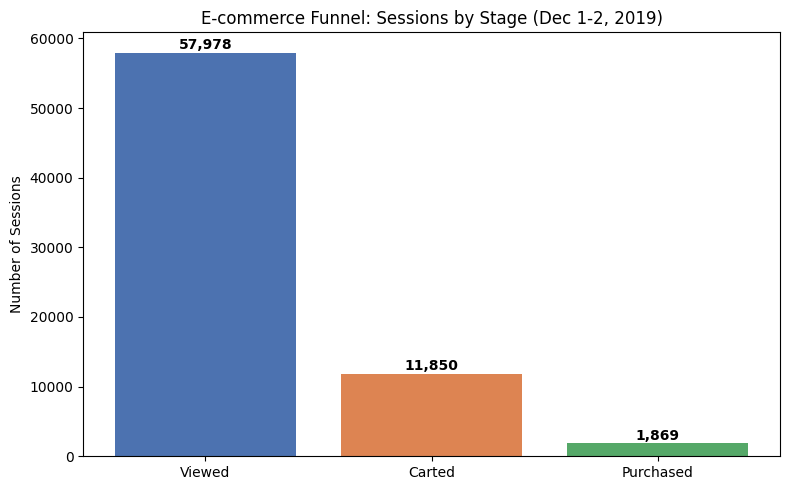

In [25]:
import matplotlib.pyplot as plt

stages = ['Viewed', 'Carted', 'Purchased']
counts = [viewed, carted, purchased]

plt.figure(figsize=(8, 5))
bars = plt.bar(stages, counts, color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('E-commerce Funnel: Sessions by Stage (Dec 1-2, 2019)')
plt.ylabel('Number of Sessions')

# Add count labels on top of bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
              f'{count:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/funnel_chart.png', dpi=150)
plt.show()

In [27]:
from google.colab import files
files.download('/content/funnel_chart.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>